<a href="https://colab.research.google.com/github/Lucaschewitch/Machine-Learning/blob/main/%D0%9F%D0%A012.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №4. Работа с векторными данными в GeoPandas**

Выполняя практическую работу, опирайтесь на теоритический материал, рассматриваемый на занятии:

- Использование NumPy, Pandas и GeoPandas для работы с пространственными данными: https://u.to/rk86Ig
- Ультимативный обзор аналитических инструментов GeoPandas:  https://u.to/s0d3Ig
- Теоретические аспекты и практические примеры получения векторных данных из OpenStreetMap: https://u.to/9SdwIQ

Дополнительно:

- Особенности построения интерактивных карт с помощью библиотеки Leafmap: https://u.to/WvA3Ig

Официальная техническая документацию по используемым библиотекам:

- **NumPy**: https://numpy.org/doc/stable/
- **Pandas**: https://pandas.pydata.org/docs/
- **GeoPandas**: https://geopandas.org/en/stable/docs.html
- **Leafmap**: https://leafmap.org/

In [2]:
%%capture
!pip install geopandas leafmap mapclassify # Устанавливаем библиотеку GeoPandas и необходимые зависимости

## **Задание №1. Операции с массивами NumPy и геопространственными координатами**


1. Создайте двумерный массив NumPy, содержащий широту и долготу следующих городов: Токио (35.6895, 139.6917), Нью-Йорк (40.7128, -74.0060), Лондон (51.5074, -0.1278) и Париж (48.8566, 2.3522).


In [3]:
# Ваш код
import numpy as np

c = np.array([[35.6895, 139.6917], [40.7128, -74.0060], [51.5074, -0.1278], [48.8566, 2.3522]])
print(c)

[[ 3.568950e+01  1.396917e+02]
 [ 4.071280e+01 -7.400600e+01]
 [ 5.150740e+01 -1.278000e-01]
 [ 4.885660e+01  2.352200e+00]]


2. Преобразуйте значения широты и долготы из градусов в радианы с помощью функции np.radians().


In [4]:
# Ваш код
rad = np.radians(c)
print(rad)

[[ 6.22899283e-01  2.43808010e+00]
 [ 7.10572408e-01 -1.29164837e+00]
 [ 8.98973719e-01 -2.23053078e-03]
 [ 8.52708531e-01  4.10536347e-02]]




3. Рассчитайте поэлементную разницу между координатами Токио и других городов в радианах.

In [5]:
# Ваш код
d = rad - rad[0]
print(d)

[[ 0.          0.        ]
 [ 0.08767312 -3.72972847]
 [ 0.27607444 -2.44031063]
 [ 0.22980925 -2.39702647]]


## **Задание 2. Операции с DataFrame Pandas и геопространственными данными**


1. Загрузите набор данных о городах мира по следующему URL с помощью Pandas: https://github.com/opengeos/datasets/releases/download/world/world_cities.csv




```python
import pandas as pd
# Pandas поддерживает загрузку данных по прямым ссылкам из сети Интернет
url = "https://github.com/opengeos/datasets/releases/download/world/world_cities.csv"

df = pd.read_csv(url)
```



In [6]:
# Ваш код
import pandas as pd

url = "https://github.com/opengeos/datasets/releases/download/world/world_cities.csv"
d = pd.read_csv(url)

2. Отобразите первые 5 строк и проверьте наличие отсутствующих значений.


In [7]:
# Ваш код
print(d.head())
print("\nПропуски:\n", d.isnull().sum())

   id         name country  latitude  longitude  population
0   1        Bombo     UGA    0.5833    32.5333       75000
1   2  Fort Portal     UGA    0.6710    30.2750       42670
2   3      Potenza     ITA   40.6420    15.7990       69060
3   4   Campobasso     ITA   41.5630    14.6560       50762
4   5        Aosta     ITA   45.7370     7.3150       34062

Пропуски:
 id            0
name          0
country       0
latitude      0
longitude     0
population    0
dtype: int64


3. Отфильтруйте набор данных, чтобы включить только города с населением более 1 миллиона человек.


In [9]:
# Ваш код
p = d[d['population'] > 1_000_000]
print(f"Городов с населением >1 млн: {len(p)}")
p.head()

Городов с населением >1 млн: 392


,id,name,country,latitude,longitude,population
97,98,Turin,ITA,45.07039,7.66996,1652000
103,104,Lille,FRA,50.64997,3.08001,1044000
123,124,San Bernardino,USA,34.12038,-117.30003,1745000
124,125,Bridgeport,USA,41.17998,-73.19996,1018000
126,127,Manchester,GBR,53.50042,-2.24799,2230000


4. Сгруппируйте города по странам и рассчитайте общую численность населения для каждой страны.


In [10]:
# Ваш код
g = d.groupby('country')['population'].sum().reset_index()
g.columns = ['country', 'total_pop']
print(g.head(10))

  country  total_pop
0     AFG    4931702
1     AGO    6821544
2     ALB     895350
3     ALD      10682
4     AND      53998
5     ARE    1982492
6     ARG   20751274
7     ARM    1102000
8     ATA       3787
9     ATG      35499




5. Отсортируйте города по населению в порядке убывания и отобразите первые 10 городов.

In [15]:
# Ваш код
top = d.sort_values('population', ascending=False).head(10)
print(top[['name', 'country', 'population']])

              name country  population
1239         Tokyo     JPN    35676000
1224      New York     USA    19040000
1230   Mexico City     MEX    19028000
1240        Mumbai     IND    18978000
1245     Sao Paulo     BRA    18845000
1148         Delhi     IND    15926000
1238      Shanghai     CHN    14987000
1243       Kolkata     IND    14787000
1175         Dhaka     BGD    12797394
1217  Buenos Aires     ARG    12795000


## **Задание №3. Создание и обработка GeoDataFrames с помощью GeoPandas**


1. Загрузите набор данных о зданиях Нью-Йорка из файла GeoJSON с помощью GeoPandas: https://github.com/opengeos/datasets/releases/download/places/nyc_buildings.geojson

In [16]:
# Ваш код
import geopandas as gpd

url = "https://github.com/opengeos/datasets/releases/download/places/nyc_buildings.geojson"
g = gpd.read_file(url)
print(g.head())
print(g.columns)

   fid  height_MS  height_FM  height_avg  SQMETERS STATEFP      NAME  \
0    2      15.05      23.30       19.18   6365.72      36  New York   
1    4      23.62      46.18       34.90   3287.84      36  New York   
2    5      19.98     109.60       64.79   2011.21      36  New York   
3    9      18.50      18.18       18.34   3110.32      36  New York   
4   34      21.53      32.84       27.18   5240.89      36  New York   

                                            geometry  
0  POLYGON ((-74.00129 40.71992, -74.00061 40.719...  
1  POLYGON ((-74.0032 40.71654, -74.00265 40.7163...  
2  POLYGON ((-74.01415 40.70324, -74.01342 40.703...  
3  POLYGON ((-73.98974 40.71924, -73.98924 40.720...  
4  POLYGON ((-74.00941 40.72351, -74.00816 40.723...  
Index(['fid', 'height_MS', 'height_FM', 'height_avg', 'SQMETERS', 'STATEFP',
       'NAME', 'geometry'],
      dtype='object')


2. Создайте график контуров зданий и раскрасьте их в зависимости от высоты здания (используйте столбец `height_MS`).


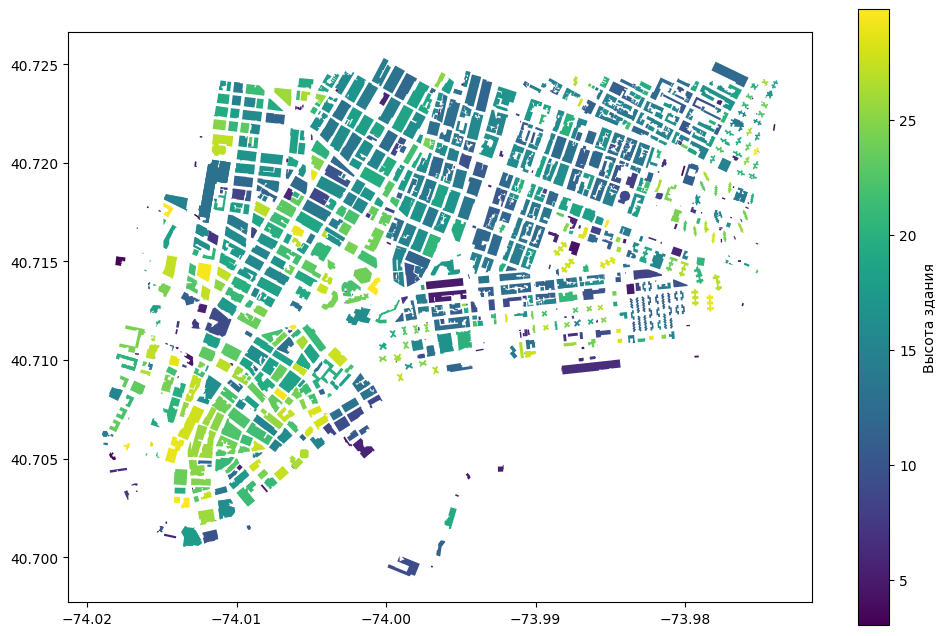

In [19]:
# Ваш код
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))
g.plot(column='height_MS', ax=ax, legend=True, cmap='viridis',
       legend_kwds={'label': 'Высота здания'})
plt.show()

3. Создайте интерактивную карту контуров зданий и раскрасьте их в зависимости от высоты здания (используйте столбец `height_MS`).


In [23]:
# Ваш код
import folium
from folium import GeoJson
import branca.colormap as cm

m = folium.Map(location=[40.7128, -74.0060], zoom_start=13)

g_clean = g.dropna(subset=['height_MS'])

vmin, vmax = g_clean['height_MS'].min(), g_clean['height_MS'].max()
colormap = cm.LinearColormap(colors=['blue', 'cyan', 'lime', 'yellow', 'red'], vmin=vmin, vmax=vmax, caption='Высота здания (м)')

def style_func(feature):
    height = feature['properties']['height_MS']
    return {'fillColor': colormap(height), 'color': 'black', 'weight': 0.5, 'fillOpacity': 0.7}

GeoJson(g_clean.to_json(), style_function=style_func, tooltip=folium.GeoJsonTooltip(fields=['height_MS'], aliases=['Высота:'], localize=True)).add_to(m)

colormap.add_to(m)

m

4. Рассчитайте среднюю высоту зданий (используйте столбец `height_MS`).


In [24]:
# Ваш код
avg_h = g['height_MS'].mean()
print(f"Средняя высота зданий: {avg_h:.2f} метров")

Средняя высота зданий: 15.45 метров


5. Выберите здания с высотой, превышающей среднюю высоту.


In [25]:
# Ваш код
high = g[g['height_MS'] > avg_h]
print(f"Количество зданий выше среднего: {len(high)}")
high.head()

Количество зданий выше среднего: 524


,fid,height_MS,height_FM,height_avg,SQMETERS,STATEFP,NAME,geometry
1,4,23.62,46.18,34.90,3287.84,36,New York,"POLYGON ((-74.0032 40.71654, -74.00265 40.7163..."
2,5,19.98,109.60,64.79,2011.21,36,New York,"POLYGON ((-74.01415 40.70324, -74.01342 40.703..."
3,9,18.50,18.18,18.34,3110.32,36,New York,"POLYGON ((-73.98974 40.71924, -73.98924 40.720..."
4,34,21.53,32.84,27.18,5240.89,36,New York,"POLYGON ((-74.00941 40.72351, -74.00816 40.723..."
5,38,18.84,NaN,18.84,1151.88,36,New York,"POLYGON ((-74.01574 40.70672, -74.01537 40.706..."





6. Сохраните GeoDataFrame в новый файл GeoJSON.

In [27]:
# Ваш код
out_file = "nyc_buildings_high.geojson"
high.to_file(out_file, driver='GeoJSON')
print(f"Сохраненяюяюяю в {out_file}")

Сохраненяюяюяю в nyc_buildings_high.geojson


## **Задание №4. Применение NumPy, Pandas и GeoPandas для обработки и анализа пространственных данных**


1. Используйте Pandas для загрузки набора данных о городах мира по следующему URL: https://github.com/opengeos/datasets/releases/download/world/world_cities.csv


In [28]:
# Ваш код
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

url = "https://github.com/opengeos/datasets/releases/download/world/world_cities.csv"
d = pd.read_csv(url)

print(d.columns)
print(d.head())

Index(['id', 'name', 'country', 'latitude', 'longitude', 'population'], dtype='object')
   id         name country  latitude  longitude  population
0   1        Bombo     UGA    0.5833    32.5333       75000
1   2  Fort Portal     UGA    0.6710    30.2750       42670
2   3      Potenza     ITA   40.6420    15.7990       69060
3   4   Campobasso     ITA   41.5630    14.6560       50762
4   5        Aosta     ITA   45.7370     7.3150       34062


2. Отфильтруйте набор данных, чтобы включить только города с широтой между -40 и 60 (т.е. города, расположенные в Северном полушарии или вблизи экватора).


In [29]:
# Ваш код
lat_col = 'latitude'
d_filt = d[(d[lat_col] >= -40) & (d[lat_col] <= 60)]
print(f"Было {len(d)} городов, осталось {len(d_filt)}")

Было 1249 городов, осталось 1132


3. Создайте GeoDataFrame из отфильтрованного набора данных, преобразовав широту и долготу в геометрии.


In [30]:
# Ваш код
lon_col = 'longitude'
city_col = 'name'

g = gpd.GeoDataFrame(d_filt, geometry=gpd.points_from_xy(d_filt[lon_col], d_filt[lat_col]), crs="EPSG:4326")
print(g.head())

   id         name country  latitude  longitude  population  \
0   1        Bombo     UGA    0.5833    32.5333       75000   
1   2  Fort Portal     UGA    0.6710    30.2750       42670   
2   3      Potenza     ITA   40.6420    15.7990       69060   
3   4   Campobasso     ITA   41.5630    14.6560       50762   
4   5        Aosta     ITA   45.7370     7.3150       34062   

                 geometry  
0  POINT (32.5333 0.5833)  
1    POINT (30.275 0.671)  
2   POINT (15.799 40.642)  
3   POINT (14.656 41.563)  
4    POINT (7.315 45.737)  


4. Перепроецируйте GeoDataFrame в проекцию Меркатора (EPSG:3857).


In [31]:
# Ваш код
g3857 = g.to_crs("EPSG:3857")
print(g3857.crs)

EPSG:3857


5. Рассчитайте расстояние (в метрах) между каждым городом и Парижем.


In [32]:
# Ваш код
paris_lat, paris_lon = 48.8566, 2.3522

paris_point_4326 = Point(paris_lon, paris_lat)
paris_point_3857 = gpd.GeoSeries([paris_point_4326], crs="EPSG:4326").to_crs("EPSG:3857").iloc[0]

dist_m = g3857.distance(paris_point_3857)

g['dist_m'] = dist_m
g['dist_km'] = g['dist_m'] / 1000

print("Минимальное расстояние, км:", g['dist_km'].min())
print("Максимальное расстояние, км:", g['dist_km'].max())

Минимальное расстояние, км: 2.7060664532526766
Максимальное расстояние, км: 22350.67639283191




6. Отобразите города на карте мира, раскрасив точки в зависимости от их расстояния до Парижа.



> 💡 **Подсказка:** Вы можете использовать интерактивную карту `leafmap.Map()` и метод m.add_data(), передав в него ваш GeoDataFrame (предварительно возвращенный в систему координат EPSG:4326).

Основные параметры данного метода:


* column — столбец с рассчитанным расстоянием до Парижа (предварительно разделите значение расстояния на 1000, чтобы легенда отображалась в километрах).
* cmap — цветовая палитра (например, "plasma", "viridis" или "YlOrRd").
* k — количество цветовых интервалов (рекомендуется 10–15 для плавности).
* scheme — алгоритм классификации данных:
  * "Quantiles" (Квантили) — делит города на группы с равным количеством точек в каждой. Это создаст максимальный цветовой контраст: даже если города расположены кучно, вы увидите разницу между ними.
   * "EqualInterval" (Равные интервалы) — делит весь диапазон расстояний на равные отрезки в километрах (например, 0-1000 км, 1000-2000 км и т.д.). Это нагляднее показывает реальный масштаб удаленности.



* установите параметр add_legend=True, чтобы на карте появилась шкала соответствия цветов и расстояний.

In [47]:
# Ваш код
import leafmap

m = leafmap.Map()

m.add_gdf(g, column="dist_km", cmap="plasma", k=12, scheme="Quantiles", add_legend=True, layer_name="Расстояние до Парижа, км")
m.add_legend = True
m

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

In [43]:
from google.colab import output
output.enable_custom_widget_manager()